In [2]:
!pip install numpy matplotlib

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import heapq

In [4]:
def create_grid(size):
    return np.zeros((size, size))

def add_obstacles(grid, num_obstacles=40):
    size = grid.shape[0]
    for _ in range(num_obstacles):
        x, y = np.random.randint(0, size, 2)
        grid[x][y] = 1
    return grid

size = 20
grid = create_grid(size)
grid = add_obstacles(grid)

grid

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0.,
        0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1.,
        0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
        0., 1., 0., 0.],
       [0., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 1.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
        0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
        0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0.,
        0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1.

In [5]:
def heuristic(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

def astar(grid, start, goal):
    rows, cols = grid.shape
    open_list = []
    heapq.heappush(open_list, (0, start))

    came_from = {}
    cost = {start: 0}

    while open_list:
        _, current = heapq.heappop(open_list)

        if current == goal:
            path = []
            while current in came_from:
                path.append(current)
                current = came_from[current]
            return path[::-1]

        neighbors = [(0,1),(1,0),(0,-1),(-1,0)]

        for dx, dy in neighbors:
            next_node = (current[0]+dx, current[1]+dy)

            if 0 <= next_node[0] < rows and 0 <= next_node[1] < cols:
                if grid[next_node] == 1:
                    continue

                new_cost = cost[current] + 1

                if next_node not in cost or new_cost < cost[next_node]:
                    cost[next_node] = new_cost
                    priority = new_cost + heuristic(goal, next_node)
                    heapq.heappush(open_list, (priority, next_node))
                    came_from[next_node] = current

    return []

In [6]:
start = (0, 0)
goal = (19, 19)

In [7]:
path = astar(grid, start, goal)

if path:
    print("✅ Path Found!")
else:
    print("❌ No Path Found")

✅ Path Found!


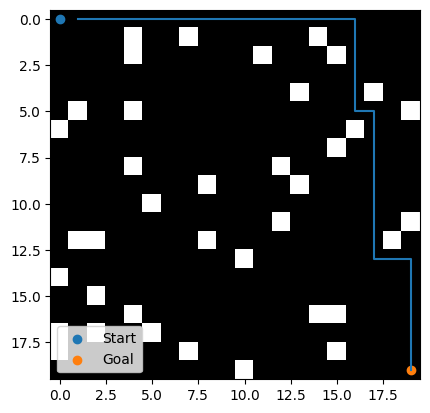

In [8]:
def show(grid, path, start, goal):
    plt.imshow(grid, cmap='gray')

    if path:
        x, y = zip(*path)
        plt.plot(y, x)

    plt.scatter(start[1], start[0], label='Start')
    plt.scatter(goal[1], goal[0], label='Goal')

    plt.legend()
    plt.show()

show(grid, path, start, goal)

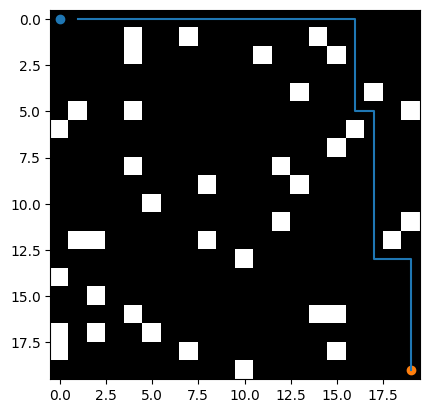

In [9]:
plt.imshow(grid, cmap='gray')

if path:
    x, y = zip(*path)
    plt.plot(y, x)

plt.scatter(start[1], start[0])
plt.scatter(goal[1], goal[0])

plt.savefig("output.png")
plt.show()

In [10]:
from google.colab import files
files.download("output.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

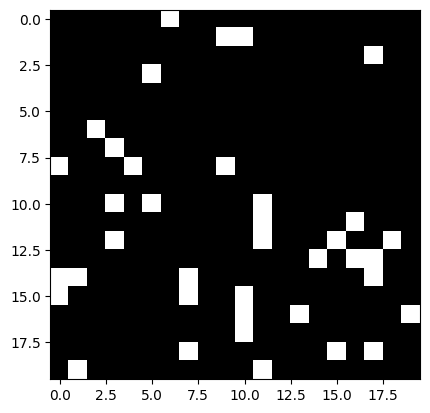

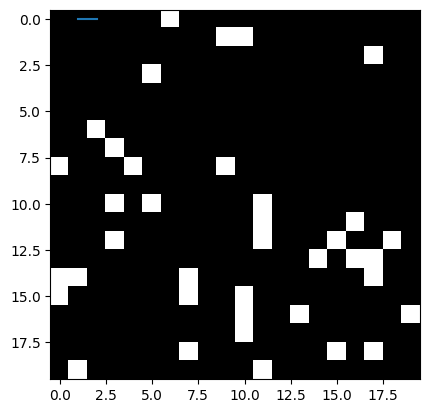

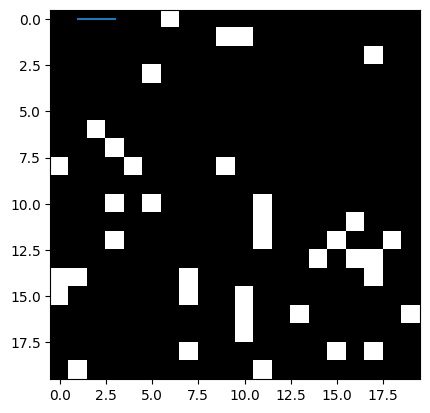

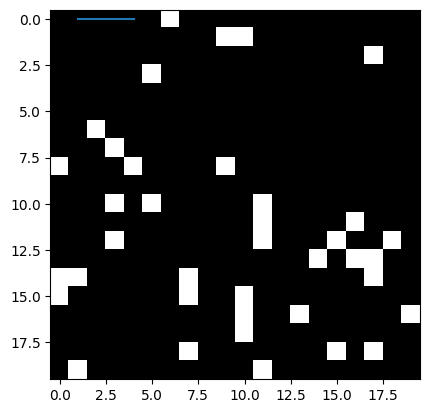

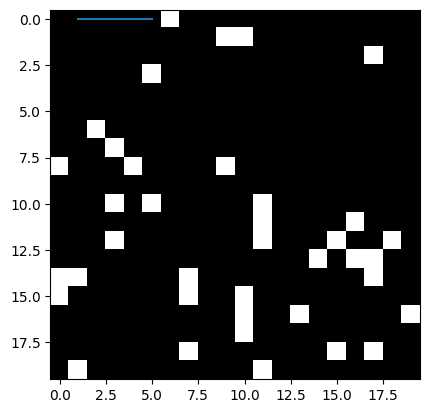

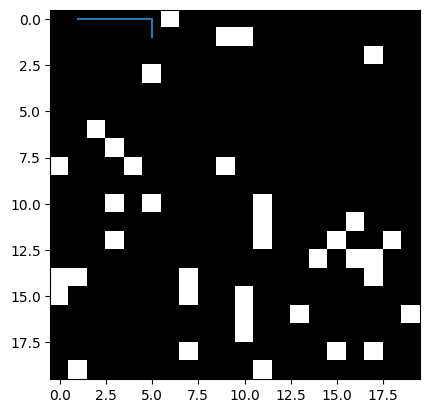

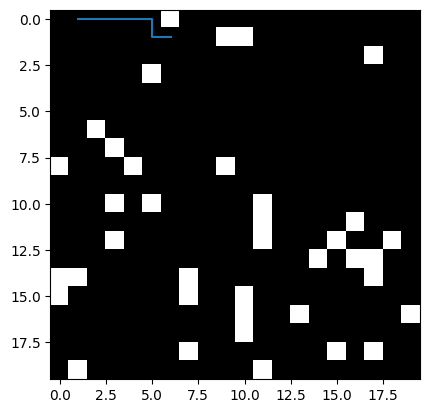

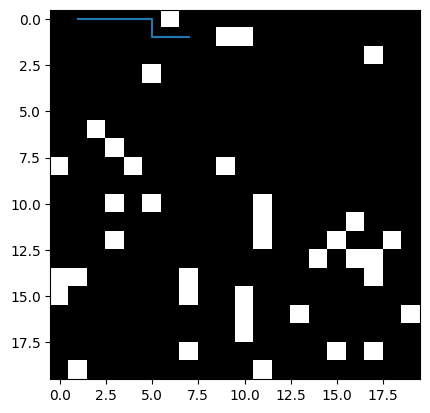

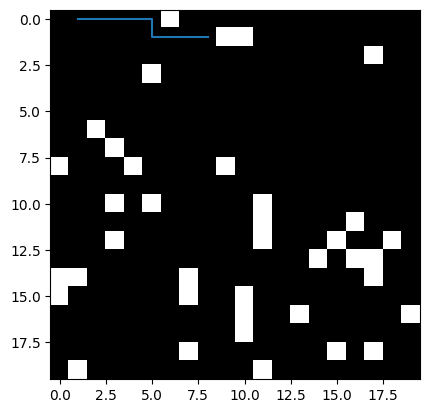

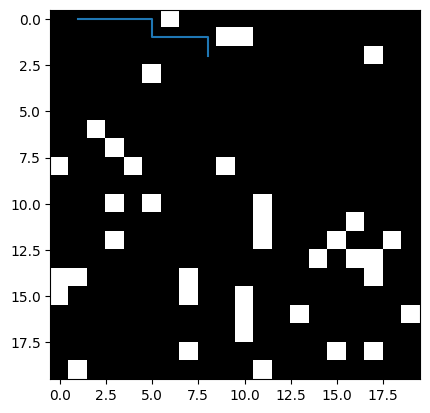

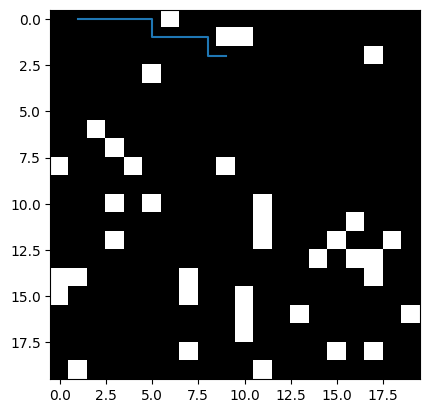

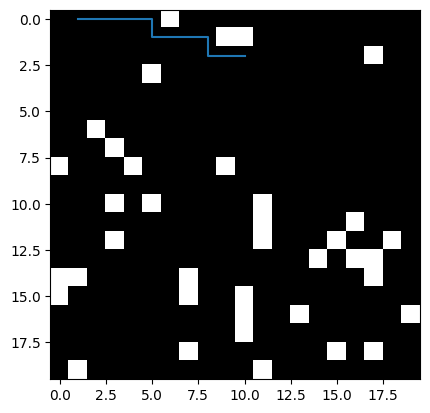

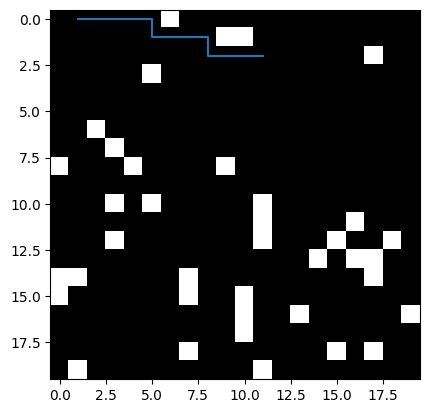

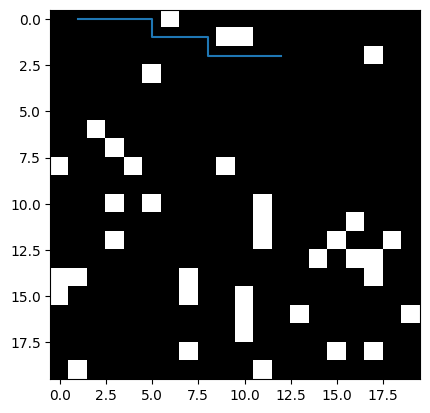

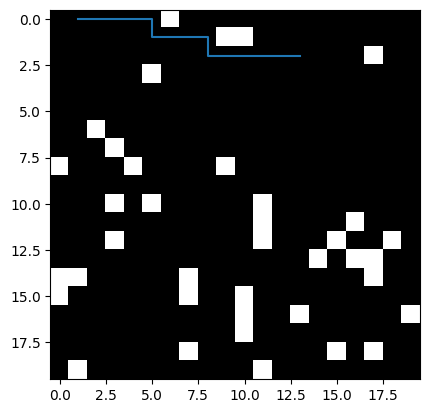

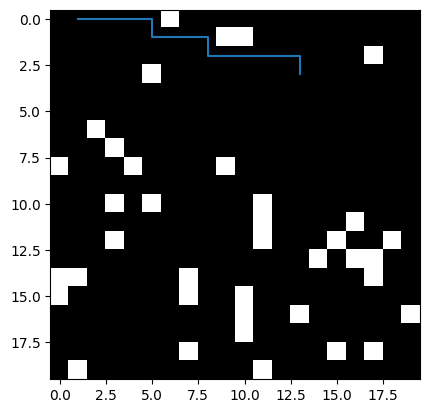

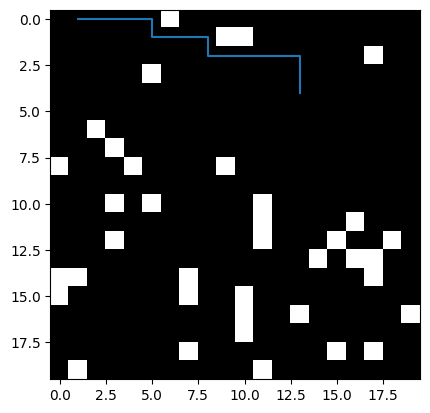

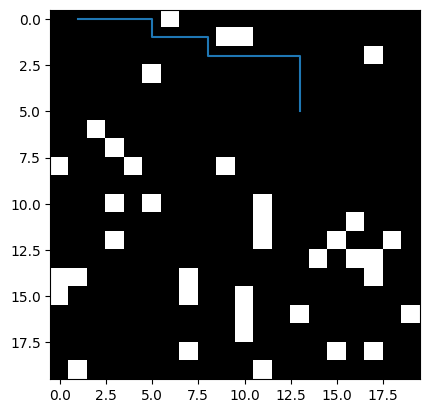

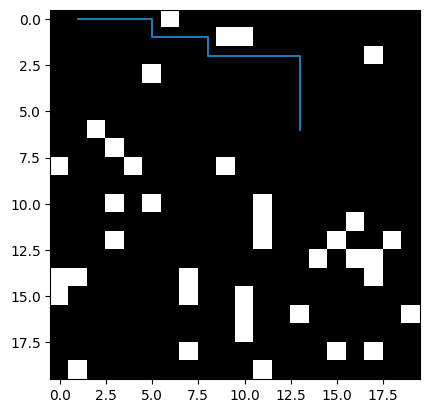

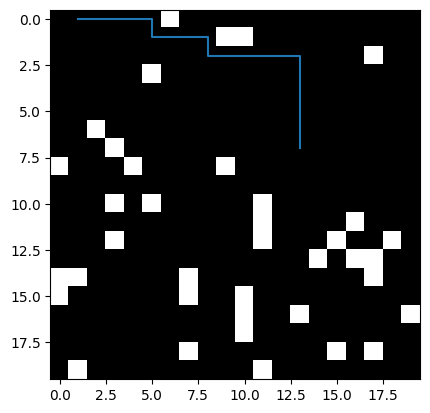

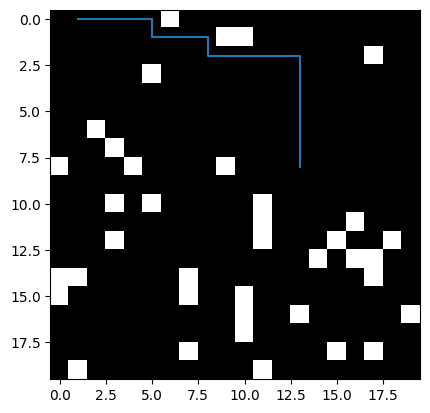

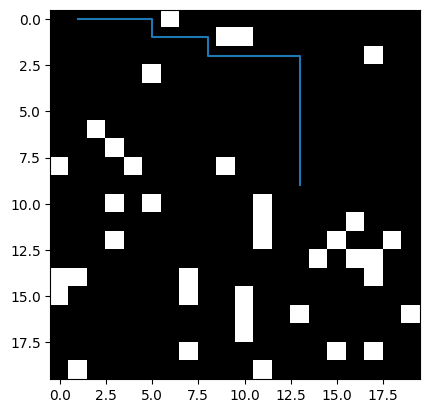

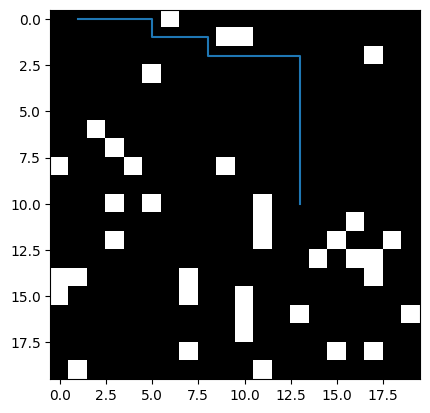

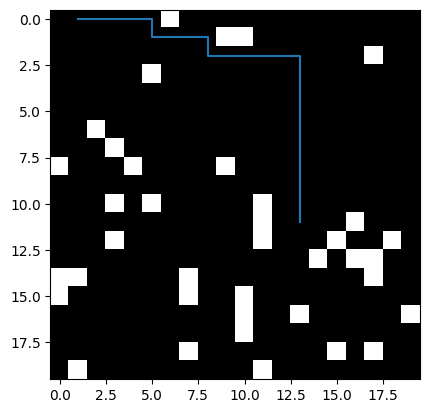

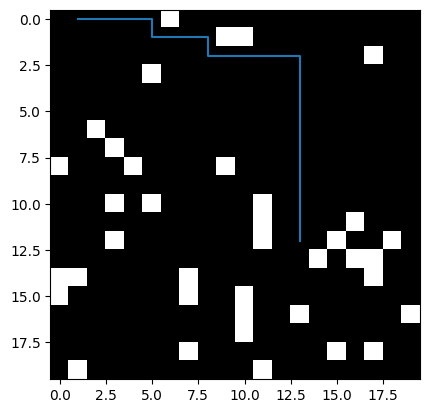

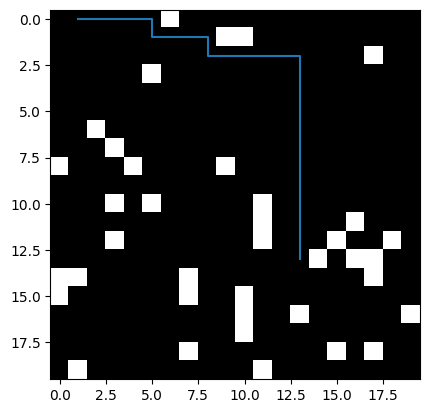

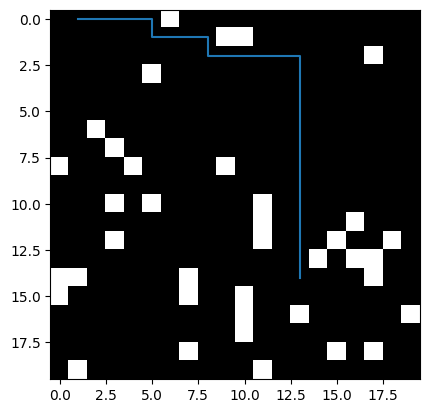

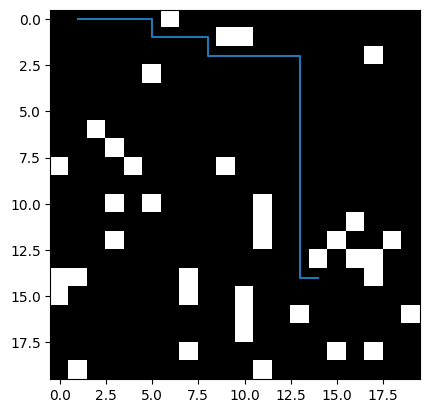

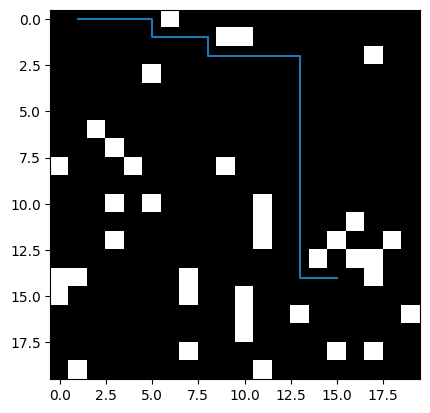

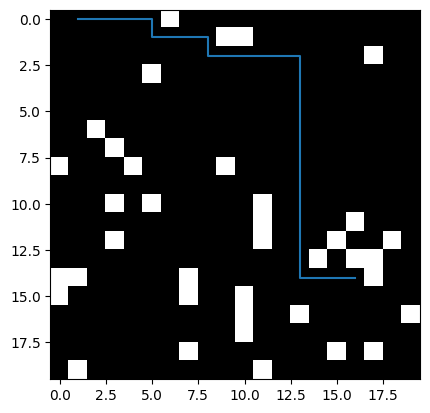

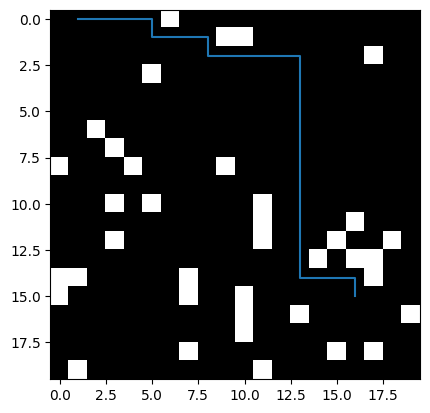

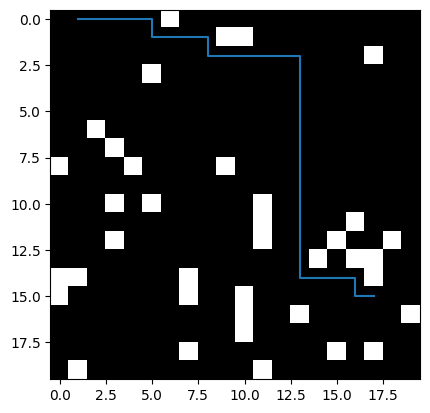

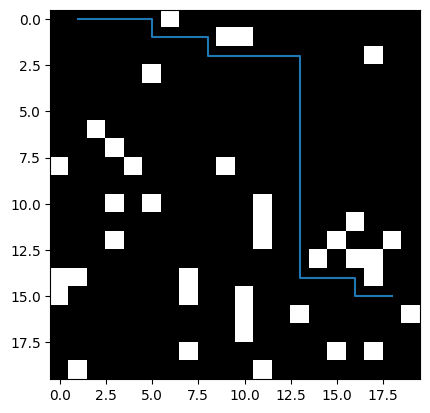

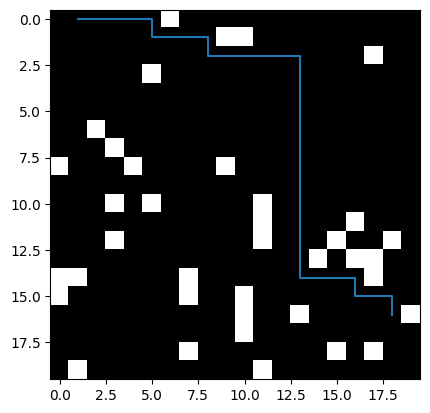

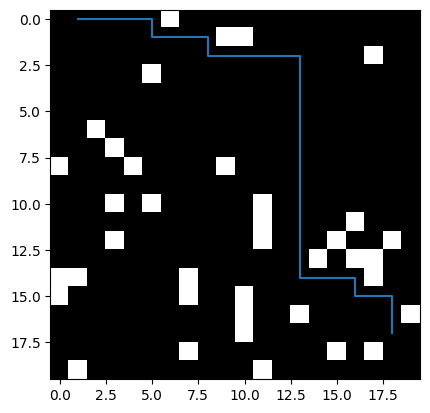

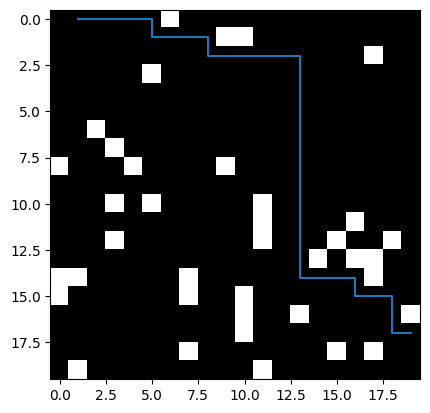

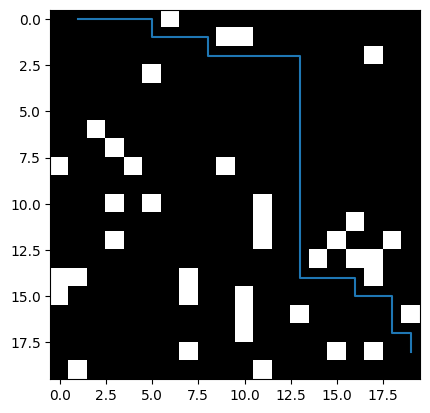

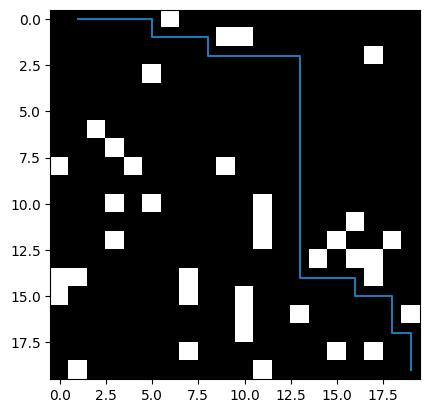

<Figure size 640x480 with 0 Axes>

In [ ]:
import time

def animate_path(grid, path):
    for i in range(len(path)):
        plt.imshow(grid, cmap='gray')
        x, y = zip(*path[:i+1])
        plt.plot(y, x)
        plt.pause(0.2)
        plt.clf()

    plt.show()

animate_path(grid, path)